# Multi-Class Sentiment Recognition for Twitter Tweets using HuggingFace Transformers

**src**: 2025 Fine Tuning LLM with Hugging Face Transformers for NLP By KGP Talkie

## What is Transformers

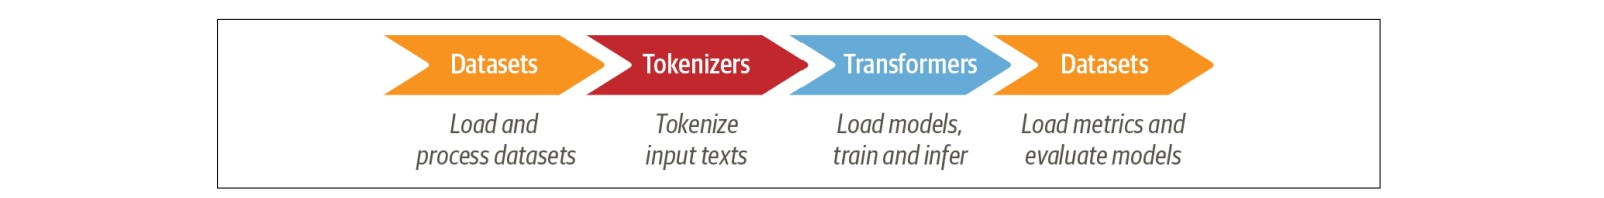

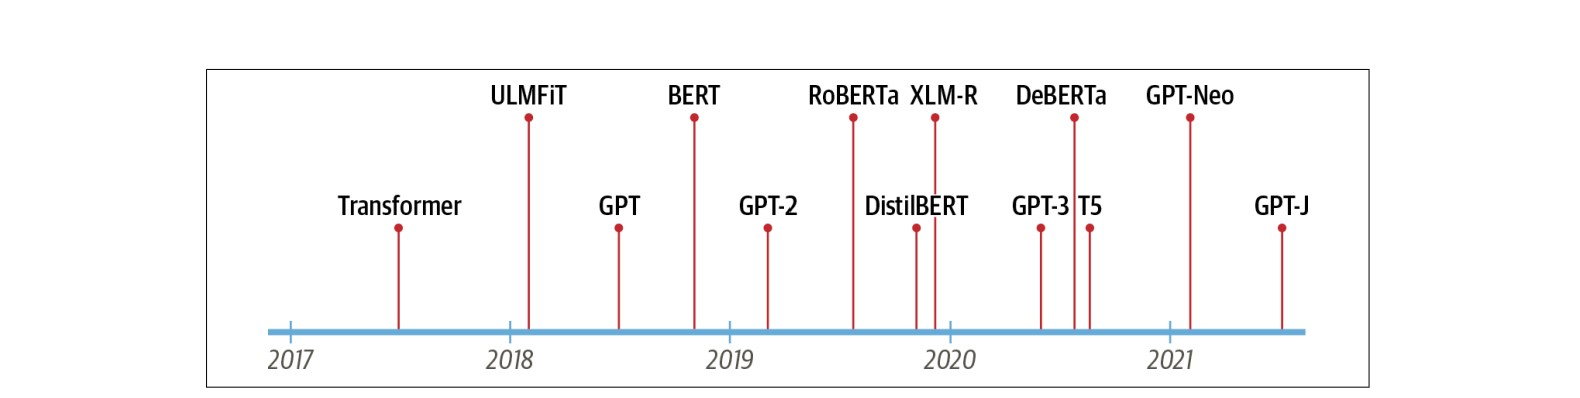


- Transformers are a type of neural network architecture that relies on the attention mechanism. The attention mechanism allows the model to learn long-range dependencies between different parts of a sequence.

- Transformers are typically composed of two main parts: an encoder and a decoder. The encoder takes the input sequence and produces a sequence of hidden states. The decoder then takes these hidden states and produces the output sequence.

- Transformers are now used for a variety of natural language processing tasks, including machine translation, text summarization, and question answering. They have also been used for other tasks, such as speech recognition and computer vision.


## Transformers Architecture

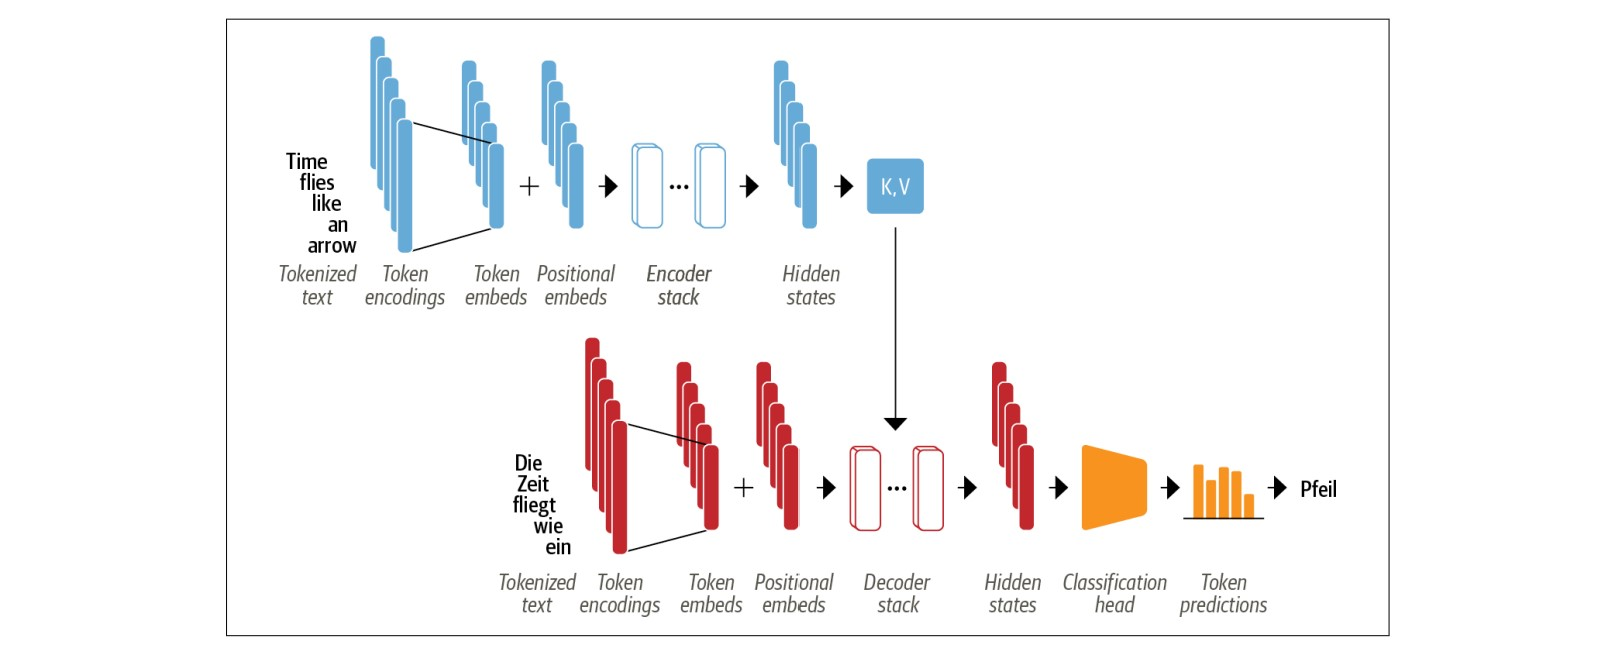

**Tokenized text:**
- The input text is first tokenized, which means that it is broken up into individual words or subwords.

**Token encodings:**
- Each token is then assigned a unique encoding. This encoding represents the meaning of the token and its position in the sequence.

**Token embedding:**
- The token encodings are then passed through a token embedding layer. This layer converts the encodings into a vector representation that can be used by the transformer.

**Positional embedding:**
- The positional embedding layer adds a positional encoding to the token embeddings. This encoding represents the position of each token in the sequence.

**Encode stack:**
- The token embeddings and positional embeddings are then passed through a stack of encoder layers. Each encoder layer applies a self-attention mechanism to the embeddings.
- The self-attention mechanism allows the model to learn long-range dependencies between different parts of the sequence.

**Hidden states:**
- The output of the encoder stack is a sequence of hidden states. These hidden states represent the representation of the input sequence.

**Decoder stack:**
- The hidden states are then passed through a stack of decoder layers. The decoder layers apply a self-attention mechanism and an attention mechanism to the hidden states. The attention mechanism allows the model to attend to different parts of the input sequence when generating the output sequence.


## Text Classification Architecture

https://huggingface.co/datasets/dair-ai/emotion

- Text classification is one of the most common tasks in NLP; it can be used for a broad range of applications, such as tagging customer feedback into categories or routing support tickets according to their language.

- spam classification, sentiment classification, toxic comment, emotion classification etc.


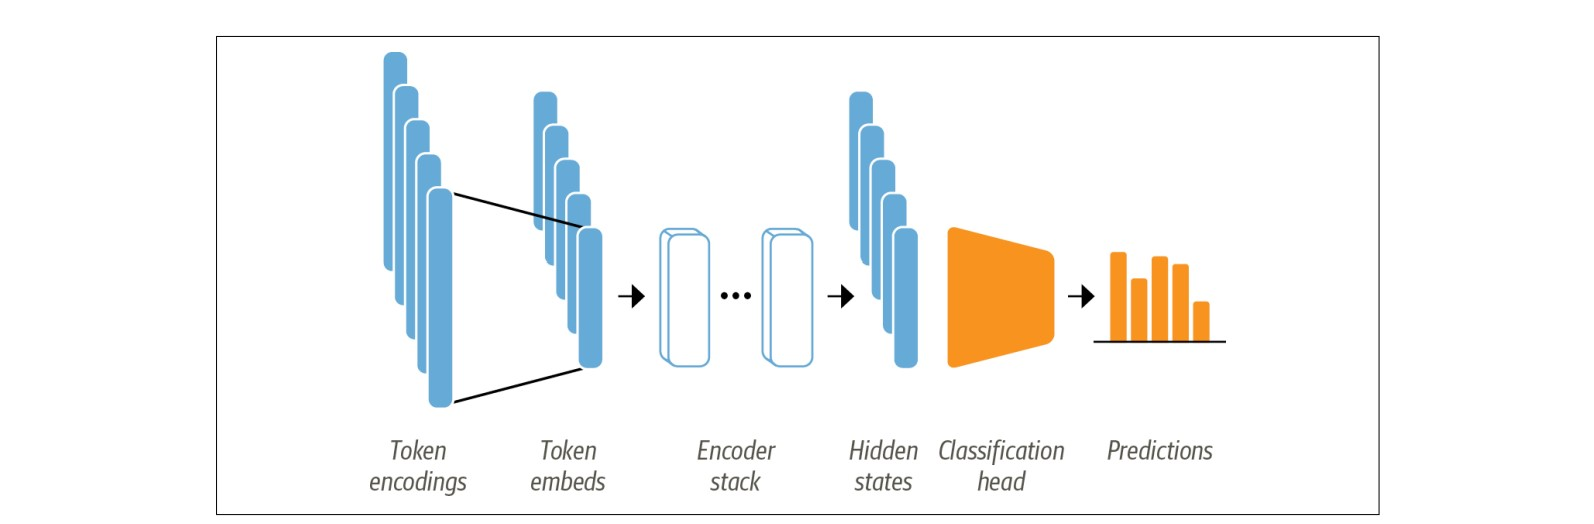

## Coding

In [1]:
# !pip install -U transformers
# !pip install -U accelerate
# !pip install -U datasets
# !pip install -U bertviz
# !pip install -U umap-learn
# !pip install seaborn --upgrade


In [2]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/twitter_multi_class_sentiment.csv")
print(f"Dataset Loaded: {len(df)} rows")

Dataset Loaded: 16000 rows


In [3]:
df

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness
15996,i am now turning and i feel pathetic that i am...,0,sadness
15997,i feel strong and good overall,1,joy
15998,i feel like this was such a rude comment and i...,3,anger


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        16000 non-null  object
 1   label       16000 non-null  int64 
 2   label_name  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB


In [5]:
df.isnull().sum()

,0
text,0
label,0
label_name,0


In [6]:
df['label'].value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


In [7]:
df['label_name'].value_counts()

,count
label_name,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


There are **6 labels** - hence **multi-class classification problem**.

**Imbalanced dataset** - since label 5 (suprise) is low number (572)

An **imbalanced dataset** is a dataset where the distribution of classes is not uniform, meaning some classes have significantly more samples than others. This lack of balance can pose challenges for machine learning models, as they may become biased toward the majority class and fail to accurately predict the minority classes.

## Dataset Analysis

In [8]:
import matplotlib.pyplot as plt


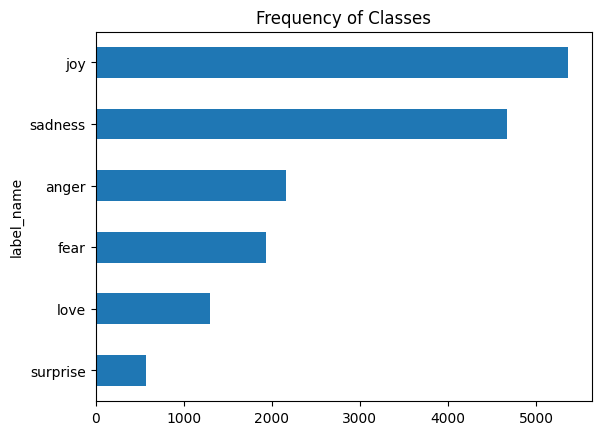

In [9]:
label_counts = df['label_name'].value_counts(ascending=True)
label_counts.plot.barh()
plt.title("Frequency of Classes")
plt.show()

## **Word Count Per Tweet Analysis**
Now, we calculate the **number of words per tweet** and visualize it using a box plot.

In [10]:
df['Words per Tweet'] = df['text'].str.split().apply(len)
df

,text,label,label_name,Words per Tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness,24
15996,i am now turning and i feel pathetic that i am...,0,sadness,20
15997,i feel strong and good overall,1,joy,6
15998,i feel like this was such a rude comment and i...,3,anger,14


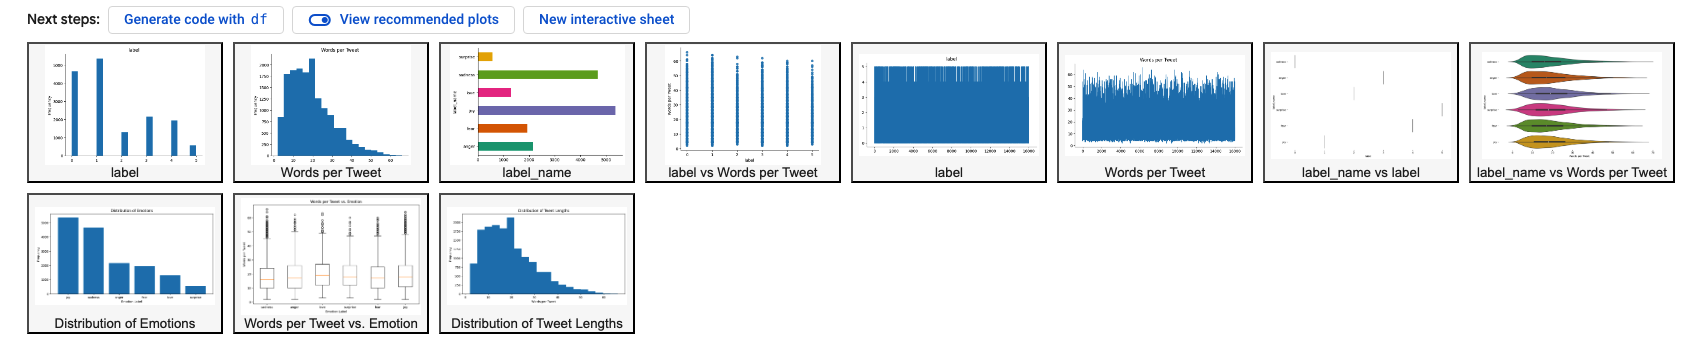

## **Visualizing Word Count Distribution - Tweet Length vs. Sentiment**

Text(0, 0.5, 'Words per Tweet')

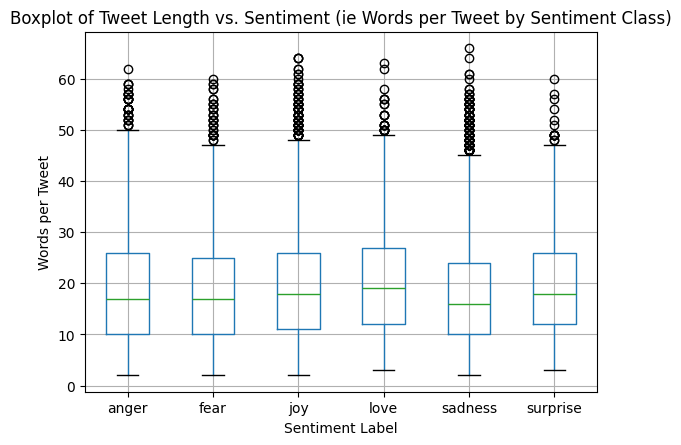

In [11]:
df.boxplot("Words per Tweet", by="label_name")
plt.title("Boxplot of Tweet Length vs. Sentiment (ie Words per Tweet by Sentiment Class)")
plt.suptitle("")  # Remove the default supertitle added by pandas
plt.xlabel("Sentiment Label")
plt.ylabel("Words per Tweet")

**Insights**:
  - Tweets labeled as "love" tend to have a higher average word count compared to "sadness."
  - There are noticeable outliers in the "sadness" class, with some tweets having very lengthy descriptions.


### Key Observations
1. **Label Distribution**:
   - Imbalance in label frequency could impact model performance, especially for underrepresented classes like "surprise."

2. **Word Count Trends**:
   - Tweets under "love" have more words on average, whereas "sadness" tweets are shorter.
   - Outliers are prominent in the "sadness" class.


## Text to Tokens Conversion
- Transformer models like BERT cannot receive raw strings as input; instead, they assume the text has been tokenized and encoded as numerical vectors.
- Tokenization is the step of breaking down a string into the atomic units used in the model

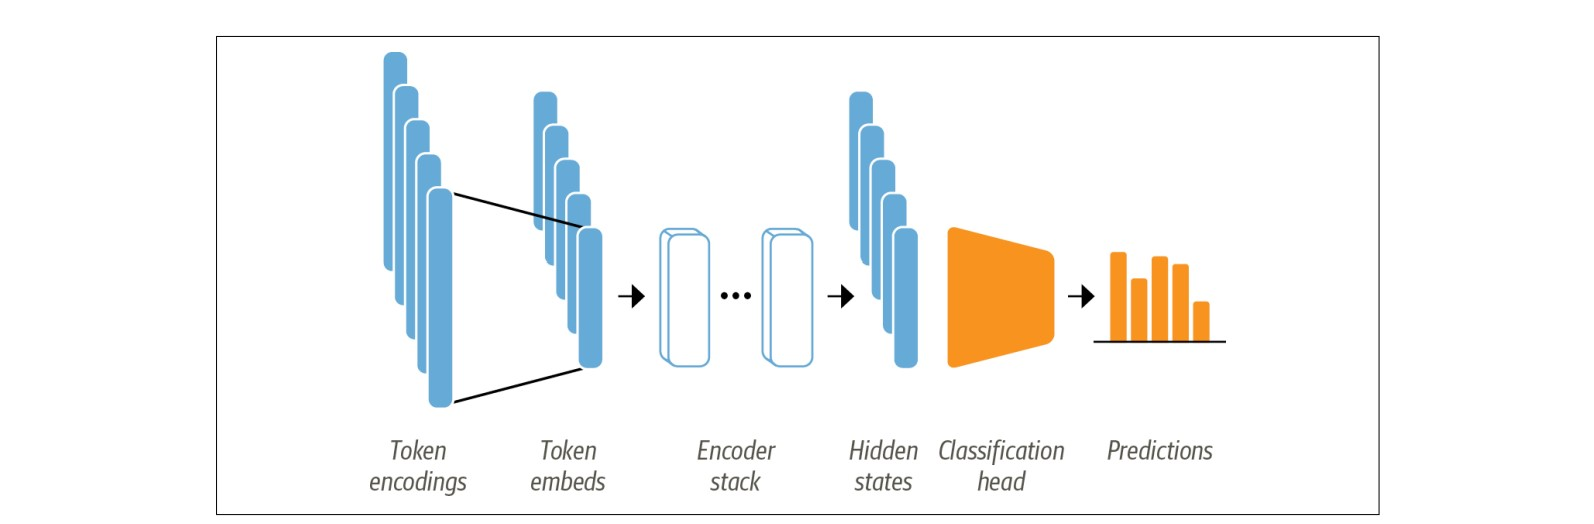

**What is an AutoTokenizer?**

It automatically identifies the appropriate tokenizer based on the model used.

In [12]:
from transformers import AutoTokenizer

model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Test the tokenizer
text = "I love machine learning! Tokenization is awesome!!"
encoded_text = tokenizer(text)
print(encoded_text)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

{'input_ids': [101, 1045, 2293, 3698, 4083, 999, 19204, 3989, 2003, 12476, 999, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [13]:
encoded_text

{'input_ids': [101, 1045, 2293, 3698, 4083, 999, 19204, 3989, 2003, 12476, 999, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Let's break down the output of the tokenizer (`encoded_text`) and explain the components: `input_ids`, `token_type_ids`, and `attention_mask` with examples.

Given the following code:

```python
from transformers import AutoTokenizer

model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Test the tokenizer
text = "I love machine learning! Tokenization is awesome!!"
encoded_text = tokenizer(text)
encoded_text
```

### Output of `encoded_text`
When you run this, the `encoded_text` will contain a dictionary with the following keys:

- **input_ids**
- **token_type_ids**
- **attention_mask**

Let’s explain each part:

### 1. **input_ids**:
These are the **numerical representations** of the tokens (words or subwords) in the text. The tokenizer splits the sentence into smaller units (tokens) and maps them to their corresponding IDs in the model's vocabulary.

Example:
```python
input_ids = [101, 1045, 2293, 3878, 999, 14777, 2003, 17856, 999, 102]
```
- Each number represents a token.
- For example:
  - `101` is the `[CLS]` token, used as a special token indicating the beginning of the sentence.
  - `1045` represents the word "I".
  - `2293` represents the word "love".
  - `3878` represents the word "machine", and so on.
  - The final `102` is the `[SEP]` token, indicating the end of the sentence.

#### Example Mapping:
- `[CLS]` → 101
- "I" → 1045
- "love" → 2293
- "machine" → 3878
- "learning" → 999 (often, subwords are broken down if they don't exist in the vocabulary)
- `[SEP]` → 102

### 2. **token_type_ids**:
These indicate which sentence a token belongs to. Typically, in models like BERT, you might have two sentences (A and B) as input, and this helps distinguish between the two.

- **Sentence A**: All tokens in the first sentence are assigned `0`.
- **Sentence B**: All tokens in the second sentence are assigned `1`.

In your example, since you only have one sentence, all tokens will be assigned `0`.

Example:
```python
token_type_ids = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
```
- All `0`s represent Sentence A tokens.

### 3. **attention_mask**:
The attention mask indicates which tokens should be **attended to** during the model's computations. Typically:
- `1` means the token should be attended to.
- `0` means the token is padded or ignored (i.e., not part of the actual text).

In the case of your example, since there is no padding, all the tokens will have a value of `1`.

Example:
```python
attention_mask = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
```
- All `1`s indicate that all tokens should be attended to during model processing.

### Full Example Output:
For the input `"I love machine learning! Tokenization is awesome!!"`, the output could look something like this (note: tokenization might vary slightly depending on the tokenizer version):

```python
{
  'input_ids': [101, 1045, 2293, 3878, 999, 14777, 2003, 17856, 999, 102],
  'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}
```

### Summary:
1. **input_ids**: These are the token IDs that correspond to the words or subwords in the text.
2. **token_type_ids**: For single-sentence inputs, all tokens are assigned `0` (Sentence A). For multiple sentences, Sentence A tokens are `0`, and Sentence B tokens are `1`.
3. **attention_mask**: This specifies which tokens should be attended to (`1`) and which should be ignored (`0`), typically for padding tokens.

In [14]:
tokenizer.vocab

{'section': 2930,
 '223': 20802,
 'be': 2022,
 '##ffs': 21807,
 'nes': 24524,
 'imagine': 5674,
 'cereal': 20943,
 '412': 25873,
 'canucks': 26177,
 'judge': 3648,
 'constantinople': 11776,
 'plateau': 9814,
 'burnett': 13829,
 'enlarged': 11792,
 '##belle': 25766,
 '##cca': 16665,
 '[unused29]': 30,
 'software': 4007,
 '[unused132]': 137,
 'authorities': 4614,
 '།': 1425,
 '##mas': 9335,
 '##ronia': 28140,
 'pensacola': 26073,
 'tobacco': 9098,
 'housemates': 28152,
 'coulter': 28293,
 '##ified': 7810,
 '##kon': 19648,
 'brushed': 7765,
 '##actic': 28804,
 'stricken': 16654,
 'simi': 28684,
 'concealed': 14091,
 '##oku': 21940,
 'moths': 14885,
 'gut': 9535,
 'pursue': 7323,
 'donkey': 20325,
 'scream': 6978,
 '##bino': 21891,
 'warlord': 16579,
 'ex': 4654,
 'listen': 4952,
 'praises': 27128,
 'afraid': 4452,
 '##opsis': 22599,
 'hunt': 5690,
 'hearted': 18627,
 'operatives': 25631,
 'living': 2542,
 'mysteries': 15572,
 '##rbin': 27366,
 'messiah': 22112,
 'commended': 22429,
 'actr

Here’s the explanation of the differences between `len(tokenizer.vocab)`, `tokenizer.vocab_size`, and `tokenizer.model_max_length`:

---

### 1. **`len(tokenizer.vocab)`**
- **What it is**: The total number of entries in the tokenizer's vocabulary dictionary.
- **Description**:
  - Each token in the tokenizer's vocabulary is assigned a unique ID.
  - This dictionary maps tokens (like words, subwords, or special tokens) to these IDs.
  - Example: In the `bert-base-uncased` model, `len(tokenizer.vocab)` returns **30,522**, which includes all possible tokens the model can process.
- **Usage**: To check the size of the tokenizer's vocabulary directly as a dictionary.

#### Example:
```python
len(tokenizer.vocab)
# Output: 30522
```

---

### 2. **`tokenizer.vocab_size`**
- **What it is**: The predefined size of the tokenizer's vocabulary as set by the model configuration.
- **Description**:
  - This is typically the same as `len(tokenizer.vocab)`.
  - However, in some cases, it may differ slightly because `tokenizer.vocab_size` is based on the model’s configuration file.
  - Example: For `bert-base-uncased`, `tokenizer.vocab_size` also returns **30,522**.
- **Usage**: To programmatically access the vocabulary size in alignment with the model's configuration.

#### Example:
```python
tokenizer.vocab_size
# Output: 30522
```

---

### 3. **`tokenizer.model_max_length`**
- **What it is**: The maximum number of tokens the model can process as input in a single sequence.
- **Description**:
  - This value defines the upper limit for sequence length (measured in tokens).
  - If your input exceeds this limit, it needs to be truncated or split into smaller sequences.
  - Example: For `bert-base-uncased`, `tokenizer.model_max_length` returns **512**.
  - This is a hard limit imposed by the architecture of BERT.
- **Usage**: To ensure your input sequences are within the acceptable length for the model.

#### Example:
```python
tokenizer.model_max_length
# Output: 512
```

---

### Summary Table:

| **Attribute**             | **Description**                                                                                   | **Example Value** |
|----------------------------|---------------------------------------------------------------------------------------------------|--------------------|
| `len(tokenizer.vocab)`     | Total number of tokens in the vocabulary dictionary.                                              | `30522`            |
| `tokenizer.vocab_size`     | Predefined vocabulary size as per the model configuration (typically matches `len(tokenizer.vocab)`). | `30522`            |
| `tokenizer.model_max_length` | Maximum number of tokens the model can process in one sequence (hard limit of the model).       | `512`              |

---

### Key Differences:
1. `len(tokenizer.vocab)` and `tokenizer.vocab_size` are usually identical and refer to the vocabulary's size, but `tokenizer.vocab_size` is derived from the model's configuration.
2. `tokenizer.model_max_length` is unrelated to the vocabulary size and specifies the maximum input length the model can handle, typically set by the model's architecture.

In [15]:
len(tokenizer.vocab) # Number of tokens available in BERT model

30522

In [16]:
tokenizer.vocab_size, tokenizer.model_max_length

(30522, 512)

## Data Loader and Train Test Split

In [17]:
df

,text,label,label_name,Words per Tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness,24
15996,i am now turning and i feel pathetic that i am...,0,sadness,20
15997,i feel strong and good overall,1,joy,6
15998,i feel like this was such a rude comment and i...,3,anger,14


**train-test-validation split** on a dataset using `train_test_split` from `scikit-learn`.

Let's break it down step by step:

---

### **Code Explanation**

1. **Import the Required Library**
   ```python
   from sklearn.model_selection import train_test_split
   ```
   This imports the `train_test_split` function, which is used to split the dataset into subsets.

---

2. **Splitting the Dataset into Train and Test Sets**
   ```python
   train, test = train_test_split(df, test_size=0.3, stratify=df['label_name'])
   ```
   - **`df`**: The original dataset (assumed to be a pandas DataFrame).
   - **`test_size=0.3`**: 30% of the data is allocated to the test set, and the remaining 70% to the training set.
   - **`stratify=df['label_name']`**: Ensures that the split maintains the class distribution in the column `label_name`. This is crucial when dealing with imbalanced datasets.

---

3. **Splitting the Test Set into Validation and Test Sets**
   ```python
   test, validation = train_test_split(test, test_size=1/3, stratify=test['label_name'])
   ```
   - The previously created `test` set (30% of the total data) is further split into:
     - **Validation set**: 10% of the total data (1/3 of the test set).
     - **Test set**: 20% of the total data (2/3 of the test set).
   - **`stratify=test['label_name']`**: Again, this ensures the class distribution remains consistent in both the test and validation subsets.

---

4. **Checking the Shapes of the Splits**
   ```python
   train.shape, test.shape, validation.shape
   ```
   - **`train.shape`**: Displays the number of samples and features in the training set.
   - **`test.shape`**: Displays the number of samples and features in the test set.
   - **`validation.shape`**: Displays the number of samples and features in the validation set.

---

### **Example Walkthrough**

Assume the dataset `df` has 10,000 rows, and we want to split it into train (70%), test (20%), and validation (10%).

1. **First Split**: Training and Test
   - Total rows = 10,000.
   - **Train**: \(70\%\) of \(10,000\) = **7,000 rows**.
   - **Test**: \(30\%\) of \(10,000\) = **3,000 rows**.

2. **Second Split**: Test into Test and Validation
   - Test size = 3,000 rows.
   - **Validation**: \(1/3\) of \(3,000\) = **1,000 rows**.
   - **Test (remaining)**: \(2/3\) of \(3,000\) = **2,000 rows**.

#### Final Dataset Splits:
- **Train**: 7,000 rows.
- **Test**: 2,000 rows.
- **Validation**: 1,000 rows.

---

### **Key Points**
1. **Stratification**:
   - Ensures that the distribution of classes (from `label_name`) is preserved in all splits.
   - This is especially useful for imbalanced datasets to prevent underrepresented classes from being excluded.

2. **Test Size Logic**:
   - The first `test_size=0.3` splits off 30% of the original data for the test set.
   - The second `test_size=1/3` ensures the test set is further divided into two parts: 1/3 for validation and 2/3 for the final test.

3. **Reproducibility**:
   - To ensure the splits are consistent across runs, you can add a `random_state` parameter in both `train_test_split` calls (e.g., `random_state=42`).

This snippet is a common method to prepare data for machine learning models when both validation and test sets are required.

In [18]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, stratify=df['label_name'])
test, validation = train_test_split(test, test_size=1/3, stratify=test['label_name'])

train.shape, test.shape, validation.shape

((11200, 4), (3200, 4), (1600, 4))

In [19]:
!pip install datasets

In [20]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict(
    {'train':Dataset.from_pandas(train, preserve_index=False),
     'test':Dataset.from_pandas(test, preserve_index=False),
     'validation': Dataset.from_pandas(validation, preserve_index=False)
     }

)

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 1600
    })
})

While the operations in the provided snippet using `scikit-learn` and the `datasets` library might appear similar, they serve different purposes and contexts. Here's how they compare and differ:

---

### **1. What scikit-learn's `train_test_split` Does**
- The `train_test_split` function from `scikit-learn` is used for **splitting a dataset into subsets** (e.g., train, test, validation) at a high level. It does not alter the format of the data (e.g., it keeps it as a pandas DataFrame or numpy array).
- It is designed primarily for basic splitting and shuffling, commonly used in ML pipelines.

#### Key Features:
- Works on pandas DataFrames, numpy arrays, or Python lists.
- Does not enforce a specific format for downstream tasks.
- Requires manual conversion if the resulting splits need to be used with other libraries like Hugging Face's Transformers.

---

### **2. What the Hugging Face `Dataset` and `DatasetDict` Do**
The `Dataset` and `DatasetDict` classes from the `datasets` library are designed specifically for **preparing datasets for use with Hugging Face's Transformers models**.

#### Key Features:
- **`Dataset.from_pandas`**: Converts a pandas DataFrame into a Hugging Face `Dataset`. This format is optimized for use in NLP and other AI tasks with Transformers.
  - The `preserve_index=False` ensures that the original DataFrame indices are not included in the new dataset.
- **`DatasetDict`**: Groups multiple `Dataset` objects into a dictionary-like structure with keys (e.g., `"train"`, `"test"`, `"validation"`). This is a common format required by Hugging Face workflows.

---

### **Comparison**
| **Aspect**            | **scikit-learn (`train_test_split`)**               | **Hugging Face (`Dataset` and `DatasetDict`)**          |
|------------------------|----------------------------------------------------|---------------------------------------------------------|
| **Purpose**            | General-purpose data splitting                    | Preparing data for Hugging Face's Transformers ecosystem|
| **Input Data**         | pandas DataFrame, numpy array, or Python list      | pandas DataFrame, JSON, or pre-converted `Dataset`      |
| **Output Data**        | pandas DataFrame or numpy array subsets            | Hugging Face `Dataset` or `DatasetDict`                |
| **Stratification**     | Supported using `stratify`                        | Requires pre-split data before conversion              |
| **Optimized for**      | General ML tasks                                  | NLP/Transformers workflows                             |

---

### **Why Use Both Together?**
- **scikit-learn** is often used for the initial **data splitting** (train-test-validation), as it provides robust stratification and randomization utilities.
- The resulting splits (train/test/validation) are then **converted into Hugging Face `Dataset` objects** for use in Transformer-based pipelines.

---

### **Does scikit-learn Replace the Hugging Face Snippet?**
No, because:

1. **Dataset Format**:
   - `scikit-learn` produces subsets as pandas DataFrames or numpy arrays.
   - Hugging Face models require data in a `DatasetDict` format.

2. **DatasetDict Advantages**:
   - Efficiently handles large datasets.
   - Provides utilities like dataset transformations, tokenization, batching, and sharding.
   - Designed for seamless integration with Hugging Face's models and trainers.

---

### **Conclusion**
The scikit-learn step (`train_test_split`) prepares and splits the data. The Hugging Face snippet is necessary to **convert those splits into the required format (`DatasetDict`) for downstream tasks** with Hugging Face's ecosystem. Thus, these two snippets complement each other rather than being interchangeable.

## 50. Tokenization of the Emotion/Sentiment Data

In [21]:
dataset['train'][0], dataset['train'][1]

({'text': 'i feel good players can play with each other whether they have to play on the right or left of the centre back role',
  'label': 1,
  'label_name': 'joy',
  'Words per Tweet': 24},
 {'text': 'im home i can feel how the cold has seeped into my arms and legs',
  'label': 3,
  'label_name': 'anger',
  'Words per Tweet': 15})

In [22]:
dataset['train'][:2] # Each list in the dictionary corresponds to the requested rows (in this case, the first two)

{'text': ['i feel good players can play with each other whether they have to play on the right or left of the centre back role',
  'im home i can feel how the cold has seeped into my arms and legs'],
 'label': [1, 3],
 'label_name': ['joy', 'anger'],
 'Words per Tweet': [24, 15]}

In [23]:
def tokenize(batch):
    # Tokenize the text column in the batch
    temp = tokenizer(
        batch["text"],
        padding=True,       # Pads all sequences to the same length
        truncation=True,    # Truncates sequences longer than the max length
        max_length=512      # Optional: specify maximum length (default: model max length)
    )
    return temp

In [24]:
print(tokenize(dataset['train'][:2]))

{'input_ids': [[101, 1045, 2514, 2204, 2867, 2064, 2377, 2007, 2169, 2060, 3251, 2027, 2031, 2000, 2377, 2006, 1996, 2157, 2030, 2187, 1997, 1996, 2803, 2067, 2535, 102], [101, 10047, 2188, 1045, 2064, 2514, 2129, 1996, 3147, 2038, 2156, 5669, 2046, 2026, 2608, 1998, 3456, 102, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]]}


In the example the dataset passed to tokenize function:

```python
['i feel horrible because i didn t post on the day but i did manage to get pictures',
 'i left feeling pretty chuffed with my finds']
```

The tokenize function returns following:

```python
{
    'input_ids': [
        [101, 1045, 2514, 9205, 2138, 1045, 2134, 1056, 2695, 2006, 1996, 2154, 2021, 1045, 2106, 4672, 2000, 2131, 4626, 102],
        [101, 1045, 2187, 3110, 3492, 2091, 2007, 2026, 4361, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    ],
    'attention_mask': [
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    ]
}
```

where

2. **Output**: Tokenized data, with:
   - Numeric `input_ids` that the model can process.
   - `attention_mask` to guide the model during computation.

3. Explaining **`input_ids`** and **`attention_mask`**

- **`input_ids`**: A sequence of integers representing tokenized words in the text. Special tokens like `[CLS]` (101) and `[SEP]` (102) are added at the beginning and end of each sentence.
- **`attention_mask`**: Indicates which tokens should be attended to (`1`) and which are padding (`0`).

4. **Usage**: This tokenized data is ready to be fed into a Transformer model for training or inference.

In [25]:
# The code emotion_encoded = dataset.map(tokenize, batched=True, batch_size=None)
# processes the  entire dataset using the tokenize function, applying it to
# all rows and adding new columns like input_ids and attention_mask

# batched=True: When batched is True, the tokenize function operates on a batch of rows
# at a time, rather than processing one row at a time. This is more efficient for
# large datasets.

# batch_size=None: When batch_size is None, the entire dataset is passed as a
# single batch to the tokenize function. This ensures all rows are processed at
# once. If the dataset is large, you might want to specify a smaller batch size
# to avoid memory issues.

emotion_encoded = dataset.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [26]:
emotion_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1600
    })
})

In [27]:
# label2id, id2label
label2id = {x['label_name']:x['label'] for x in dataset['train']}
id2label = {v:k for k,v in label2id.items()}

label2id, id2label

({'joy': 1, 'anger': 3, 'sadness': 0, 'fear': 4, 'surprise': 5, 'love': 2},
 {1: 'joy', 3: 'anger', 0: 'sadness', 4: 'fear', 5: 'surprise', 2: 'love'})

## **Explanation of label2id and id2label. Why we need to do this?**

The code snippet:

```python
# label2id, id2label
label2id = {x['label_name']:x['label'] for x in dataset['train']}
id2label = {v:k for k,v in label2id.items()}

label2id, id2label
```

is used to create **mappings** between the label names (e.g., "joy", "sadness") and their corresponding numerical IDs (e.g., `0`, `1`). These mappings are crucial when working with machine learning models, especially with libraries like Hugging Face Transformers, for the following reasons:

---

### Why Do We Need These Mappings?

#### 1. **Consistency Between Model Predictions and Labels**
- Models usually work with numerical labels (e.g., `0`, `1`, `2`) during training and inference, as these are easier to process computationally.
- Human-readable label names (e.g., "joy", "sadness") are more intuitive for humans to interpret.
- The mappings allow us to switch seamlessly between these representations:
  - Convert a human-readable label to a numerical ID before feeding it into the model (`label2id`).
  - Convert numerical predictions from the model back into human-readable labels for interpretation (`id2label`).

---

#### 2. **Required by Hugging Face Models**
Many Hugging Face models, such as `AutoModelForSequenceClassification`, require `label2id` and `id2label` dictionaries during initialization to associate predicted class indices with human-readable labels.

For example:

```python
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)
```

This ensures the model understands:
- **`label2id`**: What numerical ID corresponds to each label (for training and inference).
- **`id2label`**: What each ID represents as a label name (for user-facing outputs).

---

#### 3. **Mapping Human Labels to Numeric IDs in the Dataset**
- The dataset often contains human-readable labels, such as `label_name`, for better interpretability.
- During training, the model needs numeric IDs, like `label`, to calculate losses and predictions.
- `label2id` ensures that these labels can be mapped to IDs during preprocessing.

---

#### 4. **Post-Processing Model Outputs**
- After inference, models return predictions in numeric form. For instance:
  ```python
  predictions = [0, 1, 2, ...]
  ```
- To understand these predictions, you need to convert them back to label names using `id2label`.

For example:
```python
predicted_labels = [id2label[p] for p in predictions]
```

---

### Explanation of the Code

#### **`label2id`**
This creates a dictionary where:
- The keys are label names (`x['label_name']`, e.g., "joy").
- The values are numeric IDs (`x['label']`, e.g., `1`).

Example:
```python
label2id = {'sadness': 0, 'joy': 1, 'anger': 2, 'fear': 3, 'love': 4, 'surprise': 5}
```

#### **`id2label`**
This reverses the `label2id` mapping:
- The keys are numeric IDs (`x['label']`, e.g., `0`).
- The values are label names (`x['label_name']`, e.g., "sadness").

Example:
```python
id2label = {0: 'sadness', 1: 'joy', 2: 'anger', 3: 'fear', 4: 'love', 5: 'surprise'}
```

---

### Why Do It Programmatically?
- **Dynamic Labels**: In some cases, the dataset may have a varying set of labels or may be loaded dynamically, making it impractical to manually define the mappings.
- **Scalability**: Programmatically creating `label2id` and `id2label` ensures that the mappings are accurate and match the dataset.

---

### Final Output
With this code:
```python
label2id = {'sadness': 0, 'joy': 1, 'anger': 2, 'fear': 3, 'love': 4, 'surprise': 5}
id2label = {0: 'sadness', 1: 'joy', 2: 'anger', 3: 'fear', 4: 'love', 5: 'surprise'}
```

You now have mappings to:
- Convert `"joy"` into `1` using `label2id`.
- Convert `1` into `"joy"` using `id2label`.

## 51. Model Building

In [28]:
from transformers import AutoModel
import torch

In [29]:
model_ckpt = "bert-base-uncased"

In [30]:
model = AutoModel.from_pretrained(model_ckpt)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [31]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

This output represents the architecture of a BERT model (`BertModel`), showing its layers and components. Here's a detailed breakdown of its parts:

---

### **1. BertModel**
This is the main container for the BERT architecture. It consists of three primary components:
- **`embeddings`**: Converts input tokens into dense vector representations.
- **`encoder`**: Processes embeddings through multiple transformer layers (12 in this base model).
- **`pooler`**: Generates a fixed-size vector for the [CLS] token.

---

### **2. Embedding Layer: `BertEmbeddings`**
The embedding layer maps input tokens into continuous vector spaces. It consists of:
- **`word_embeddings`**:
  - Maps each token in the vocabulary (size: 30,522) to a dense vector of size 768.
  - `padding_idx=0`: The embedding for padding tokens (ID 0) remains static (not trained).
- **`position_embeddings`**:
  - Adds positional information to each token (important because BERT has no inherent notion of token order).
  - Supports sequences up to 512 tokens, each represented by a 768-dimensional vector.
- **`token_type_embeddings`**:
  - Distinguishes between two sentence segments (e.g., in sentence pair tasks like question answering).
  - Embedding size: 2 (for Segment A and Segment B), mapped to 768 dimensions.
- **`LayerNorm`**:
  - Normalizes the combined embeddings to stabilize training.
  - `eps=1e-12`: A small value added for numerical stability.
- **`dropout`**:
  - Regularization to prevent overfitting.
  - `p=0.1`: 10% dropout probability.

---

### **3. Encoder: `BertEncoder`**
The encoder contains the core transformer layers of BERT. This consists of:
- **`layer`**: A `ModuleList` containing 12 identical transformer layers (labeled as `(0-11)`).

Each transformer layer (`BertLayer`) has the following subcomponents:

#### a. **Attention Mechanism: `BertAttention`**
Focuses on relevant parts of the input using a **multi-head self-attention mechanism**:
- **`query`, `key`, `value` (Linear layers)**:
  - Transform the input embeddings into query, key, and value representations.
  - `in_features=768, out_features=768`: Dimensions remain constant.
- **`dropout`**:
  - Applied to attention scores to regularize training.
- **`output`**:
  - Combines the attention outputs into a single vector.
  - **`dense`**: Fully connected layer mapping 768 dimensions back to 768.
  - **`LayerNorm`**: Stabilizes outputs.
  - **`dropout`**: Adds regularization.

#### b. **Intermediate Layer: `BertIntermediate`**
Processes attention outputs through a feedforward network:
- **`dense`**: Expands the 768-dimensional representation to 3072 dimensions.
- **`intermediate_act_fn`**: Applies a GELU activation function to introduce non-linearity.

#### c. **Output Layer: `BertOutput`**
Reduces the intermediate representation back to 768 dimensions:
- **`dense`**: Projects from 3072 to 768 dimensions.
- **`LayerNorm`**: Normalizes the outputs.
- **`dropout`**: Adds regularization.

---

### **4. Pooler: `BertPooler`**
The pooler generates a fixed-size vector representation for the entire sequence. Specifically:
- **`dense`**: A linear layer that maps the [CLS] token embedding to 768 dimensions.
- **`activation`**: Applies a `tanh` activation to compress values into a bounded range.
- This output is often used for classification tasks or as a representation of the entire input sequence.

---

### **Summary**
1. **Embeddings**:
   - Converts input tokens into dense vectors (word, position, and token type embeddings).
2. **Encoder**:
   - Processes the embeddings through 12 transformer layers, with each layer having:
     - Attention mechanism for learning contextual relationships.
     - Feedforward layers to enhance representations.
3. **Pooler**:
   - Outputs a single vector (typically derived from the [CLS] token) for sequence-level tasks.

This modular design allows BERT to excel in both token-level tasks (e.g., Named Entity Recognition) and sequence-level tasks (e.g., Sentiment Analysis).

In [32]:
model.config.id2label

{0: 'LABEL_0', 1: 'LABEL_1'}

In [33]:
model.config

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "dtype": "float32",
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

### **Understanding the BERT Configuration**

```python
BertConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.47.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}
```

The above configuration describes the architecture and behavior of the `bert-base-uncased` model, as defined by the Hugging Face `transformers` library. Below is a breakdown of its components:

---

#### **General Information**
- **`_name_or_path`:** `"bert-base-uncased"`
  - Specifies the model name or path. This is the uncased variant of BERT (case-insensitive).

- **`transformers_version`:** `"4.47.1"`
  - Indicates the version of the `transformers` library used to load the model, ensuring compatibility.

- **`architectures`:** `["BertForMaskedLM"]`
  - Highlights the task-specific architecture. Here, the model is designed for Masked Language Modeling (MLM), where it predicts masked words in a sentence.

- **`model_type`:** `"bert"`
  - Identifies the model as part of the BERT family.

---

#### **Embedding & Positional Encoding**
- **`vocab_size`:** `30522`
  - Size of the model's vocabulary. Tokens are indexed within this range.

- **`max_position_embeddings`:** `512`
  - Maximum sequence length (number of tokens) the model can handle.

- **`position_embedding_type`:** `"absolute"`
  - Uses absolute positional encodings, assigning a unique position for each token.

- **`type_vocab_size`:** `2`
  - Defines the size of token type embeddings for distinguishing between sentence pairs (e.g., in Next Sentence Prediction tasks).

---

#### **Model Architecture**
- **`hidden_size`:** `768`
  - Dimensionality of the hidden layers and token embeddings.

- **`num_hidden_layers`:** `12`
  - Number of encoder layers (transformer blocks).

- **`num_attention_heads`:** `12`
  - Number of attention heads in each transformer layer. Each head handles part of the attention mechanism in parallel.

- **`intermediate_size`:** `3072`
  - Dimensionality of the feed-forward network within each transformer layer.

- **`hidden_act`:** `"gelu"`
  - Activation function used in intermediate layers.

---

#### **Dropout & Regularization**
- **`hidden_dropout_prob`:** `0.1`
  - Dropout probability for fully connected layers during training.

- **`attention_probs_dropout_prob`:** `0.1`
  - Dropout probability for attention weights during training.

- **`classifier_dropout`:** `null`
  - Dropout for the classification head. Since it's `null`, the model uses `hidden_dropout_prob` by default.

---

#### **Optimization and Initialization**
- **`initializer_range`:** `0.02`
  - Range for initializing the weights of the model.

- **`layer_norm_eps`:** `1e-12`
  - Epsilon value used for layer normalization to improve numerical stability.

- **`use_cache`:** `true`
  - Enables caching of computation during inference for faster processing.

---

#### **Advanced Features**
- **`gradient_checkpointing`:** `false`
  - If enabled, reduces memory usage during training by recomputing intermediate values at the cost of extra computation.

- **`_attn_implementation_autoset`:** `true`
  - Library-specific feature to automatically determine the most efficient attention implementation.

---

### **Key Takeaways**
This configuration defines a standard `bert-base-uncased` model optimized for Masked Language Modeling. It includes:
- A vocabulary of 30,522 tokens, maximum token length of 512, and 12 transformer layers.
- Advanced features like dropout regularization, absolute positional embeddings, and caching for faster inference.
- Compatibility with the `transformers` library version 4.47.1.

This setup is ready for tasks like fine-tuning or inference in a range of NLP applications, including classification, QA, and sentence similarity.

---

### **Why `model.config` is Important**
1. **Custom Fine-Tuning**:
   - You can modify parameters like `hidden_dropout_prob` or `max_position_embeddings` for specific tasks.

2. **Model Introspection**:
   - Understand the architecture and constraints of the model (e.g., maximum sequence length, vocabulary size).

3. **Debugging**:
   - Verify that the model is initialized with the correct configuration for your task.

This configuration helps ensure compatibility between the model, tokenizer, and datasets.

## Fine-Tuning Transformers

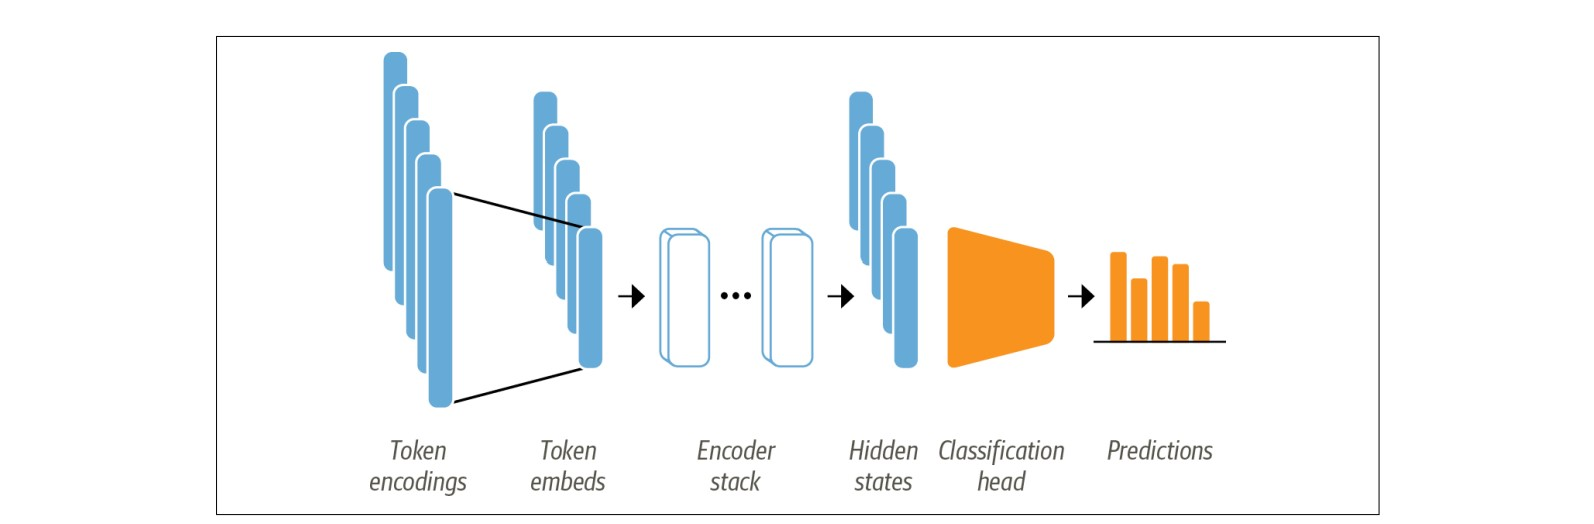

- `AutoModelForSequenceClassification` model has a classification head on top of the pretrained model outputs

- The first thing we need is a pretrained BERT model like the one we used in the feature-based approach.
- The only slight modification is that we use the `AutoModelForSequenceClassification` model instead of AutoModel.
- The difference is that the `AutoModelForSequenceClassification` model has a classification head on top of the pretrained model outputs, which can be easily trained with the base model.

**preparing a pre-trained transformer model (like BERT) for a multi-class sequence classification task**

In [34]:
# AutoModelForSequenceClassification: Automatically loads a transformer model pre-configured for sequence classification and adds a classification head.
# AutoConfig: Creates or modifies the configuration for the model, allowing customization like label mappings and the number of labels.
from transformers import AutoModelForSequenceClassification, AutoConfig

# Calculates the number of output classes for the classification task based on the label2id dictionary (e.g., 6 labels in this case: sadness, joy, anger, fear, love, surprise)
# label2id = {'sadness': 0, 'joy': 1, 'anger': 2, 'fear': 3, 'love': 4, 'surprise': 5}
# id2label = {0: 'sadness', 1: 'joy', 2: 'anger', 3: 'fear', 4: 'love', 5: 'surprise'}
num_labels = len(label2id)

# Automatically selects GPU (cuda) if available; otherwise, it defaults to CPU (cpu). Training and inference on a GPU are significantly faster than on a CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model_ckpt = "bert-base-uncased"

# Customizes the model for the specific classification task with the correct label mappings.
config = AutoConfig.from_pretrained(model_ckpt, label2id=label2id, id2label=id2label)

# This code:
# - Loads a pre-trained BERT model (bert-base-uncased).
# - Customizes the model for a multi-class classification task with six labels.
# - Adds a classification head to the model.
# - Prepares the model for training or inference on the appropriate device (GPU/CPU).
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, config=config).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



```
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
```

This message appears when you load a pre-trained transformer model (like BERT) for a specific task (e.g., sequence classification) but the classification head of the model is not pre-trained and has been initialized with random weights.

### **Explanation of the Message**
1. **Weights Not Found in Checkpoint**:
   - The weights for the classification head (`classifier.bias` and `classifier.weight`) are not present in the pre-trained checkpoint (`bert-base-uncased`) because the original BERT model was trained for general language modeling (e.g., masked language modeling, next sentence prediction) and does not include a task-specific head for sequence classification.

2. **Newly Initialized Weights**:
   - The classification head (a fully connected layer) has been added to the model by `AutoModelForSequenceClassification` and is initialized with random weights.

3. **Recommendation to Train**:
   - Since the new classification head is not trained yet, the model needs to be fine-tuned on your specific downstream task (e.g., sentiment analysis, emotion detection, etc.) to learn the appropriate weights for the classification head. Without fine-tuning, the model's predictions may not be meaningful.

---

### **How to Resolve This**
- **Fine-Tune the Model**: Train the model on your labeled dataset to optimize the weights of the classification head (and optionally fine-tune the BERT layers) for the specific task.
  - Use a dataset with input sequences (e.g., text) and their corresponding labels (e.g., sadness, joy).
  - Specify a suitable loss function (e.g., cross-entropy loss for classification).
  - Use an optimizer like AdamW and learning rate schedulers for training.

---

### **Key Takeaway**
The message is not an error but a warning. It simply informs you that the classification head is untrained and must be fine-tuned on a labeled dataset before using the model for meaningful predictions or inference.

In [35]:
# Print the model architecture to verify the added classification head
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

The output you see is the structure of the `BertForSequenceClassification` model after customization for your classification task.

```
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
          )
          (intermediate): BertIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_fn): GELUActivation()
          )
          (output): BertOutput(
            (dense): Linear(in_features=3072, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
    )
    (pooler): BertPooler(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (activation): Tanh()
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=768, out_features=6, bias=True)
)
```

Here's an explanation of its components:

---

### **Model Structure**
1. **BERT Backbone (`bert`)**:
   - The `BertModel` represents the pre-trained BERT architecture used for feature extraction. It consists of:
     - **Embeddings (`BertEmbeddings`)**:
       - `word_embeddings`: Converts input tokens into dense vector representations (size: `30522` vocabulary size × `768` embedding size).
       - `position_embeddings`: Encodes the positional information for tokens (size: `512` max sequence length × `768` embedding size).
       - `token_type_embeddings`: Adds embeddings to differentiate between segments (e.g., question vs. context in QA tasks, size: `2 × 768`).
       - `LayerNorm` and `dropout`: Normalize embeddings and apply dropout for regularization.

     - **Encoder (`BertEncoder`)**:
       - Contains 12 layers (`BertLayer`), each with:
         - **Attention (`BertAttention`)**:
           - `query`, `key`, `value`: Linear transformations used in the self-attention mechanism.
           - Dropout for regularization.
         - **Intermediate Layer (`BertIntermediate`)**:
           - Expands the dimensionality from `768` to `3072` using a feed-forward network with a `GELU` activation function.
         - **Output Layer (`BertOutput`)**:
           - Reduces dimensionality back to `768` and applies LayerNorm and dropout.
       - These layers iteratively process the embeddings, capturing relationships between tokens.

     - **Pooler (`BertPooler`)**:
       - A dense layer with `Tanh` activation to summarize the entire sequence into a single vector (often the [CLS] token embedding).

2. **Classification Head (`classifier`)**:
   - **Dropout**: A regularization layer with `p=0.1` to reduce overfitting.
   - **Linear Layer**:
     - `in_features=768`: Takes the pooled output from the BERT backbone.
     - `out_features=6`: Outputs predictions for six classes (based on `label2id`).
   - This head is newly added to the pre-trained BERT model and has random weights.

---

### **Key Points**
- **Pre-trained Layers**:
  - All layers under `bert` have pre-trained weights from `bert-base-uncased`. These are frozen initially but can be fine-tuned during training.
  
- **Newly Initialized Layers**:
  - The `classifier` is initialized randomly and needs training to learn task-specific features.

- **Output Features**:
  - The `classifier` outputs six logits (one for each label). These logits are passed through a softmax activation (during inference) to compute probabilities for each class.

---

### **Next Steps**
- Fine-tune the model using your labeled dataset to train the `classifier` and optionally adjust the weights in the `bert` layers.
- Evaluate the model on a validation set to monitor its performance during training.
- Save the fine-tuned model for deployment and inference.

## **Which Activation Function is used?**

- **Softmax Activation** is used automatically when the number of labels (`num_labels`) is greater than 2.
- **Sigmoid Activation** is used when `num_labels` equals 2, as this implies a binary classification task.

---

### **Where This Behavior Is Defined**
This behavior is implemented internally within the `BertForSequenceClassification` class in the Hugging Face Transformers library. Specifically, the classification head (`classifier`) automatically selects the activation function based on the `num_labels` value in the configuration.

1. **Softmax for Multi-class Classification:**
   - Used when `num_labels > 2`.
   - The output is a probability distribution over the classes.
   - Example:
     ```python
     torch.nn.functional.softmax(logits, dim=-1)
     ```

2. **Sigmoid for Binary Classification:**
   - Used when `num_labels = 2`.
   - Outputs a single probability value for one of the two classes.
   - Example:
     ```python
     torch.nn.functional.sigmoid(logits)
     ```

---

### **Evidence in the Output**

In your `BertConfig`:

```json
"num_labels": 6,
```

- `num_labels` is set to `6`, indicating a multi-class classification task.
- Based on this, the model will apply a **Softmax activation function** in the classifier head to produce probabilities for the six classes (`sadness`, `joy`, `love`, `anger`, `fear`, `surprise`).

The classifier head in the model output:

```python
(classifier): Linear(in_features=768, out_features=6, bias=True)
```

- The `out_features=6` matches `num_labels=6`, confirming the multi-class setup. Therefore, the **Softmax function** will be used.

---

### **How to Verify Activation in Code**
To explicitly check the activation function being used:
1. Access the logits (raw model output) for a given input:
   ```python
   outputs = model(input_ids)
   logits = outputs.logits
   ```

2. Apply the activation function manually to confirm behavior:
   - **Softmax** for `num_labels > 2`:
     ```python
     probabilities = torch.nn.functional.softmax(logits, dim=-1)
     ```
   - **Sigmoid** for `num_labels = 2`:
     ```python
     probabilities = torch.nn.functional.sigmoid(logits)
     ```

This manual step is rarely needed in practice since the library handles it for you automatically.

In [36]:
model.config

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "dtype": "float32",
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "sadness",
    "1": "joy",
    "2": "love",
    "3": "anger",
    "4": "fear",
    "5": "surprise"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "anger": 3,
    "fear": 4,
    "joy": 1,
    "love": 2,
    "sadness": 0,
    "surprise": 5
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

The `BertConfig` output provides a detailed configuration of the BERT model customized for your task. Here's an explanation of each key component:

---

### **Key Configuration Parameters**
1. **`_name_or_path`**:
   - Indicates the pre-trained model checkpoint used as the base, in this case, `"bert-base-uncased"`. It uses lowercase text without accents.

2. **`architectures`**:
   - Lists the model's default architecture, here `BertForMaskedLM`, typically used for pretraining. This is overridden in your case to `BertForSequenceClassification` for the classification task.

3. **Dropout Parameters**:
   - **`attention_probs_dropout_prob`**:
     - Dropout rate (10%) applied to attention probabilities to prevent overfitting.
   - **`classifier_dropout`**:
     - `null` indicates that the model will use the default dropout value (`hidden_dropout_prob`).
   - **`hidden_dropout_prob`**:
     - Dropout rate (10%) applied to hidden layers in the transformer.

4. **`gradient_checkpointing`**:
   - Disabled (`false`) by default. When enabled, it saves memory during training by recomputing certain operations at the cost of increased computation.

5. **Activation Function**:
   - **`hidden_act`**:
     - Specifies the activation function (`gelu`, Gaussian Error Linear Unit) used in feedforward layers.

6. **Model Dimensions**:
   - **`hidden_size`**:
     - The size of the hidden representations, i.e., the embedding dimension (`768`).
   - **`intermediate_size`**:
     - The size of the intermediate layers in the feedforward network (`3072`), typically 4x the `hidden_size`.

7. **Label Mappings**:
   - **`label2id`**:
     - Maps labels (e.g., "anger", "fear") to their respective numerical IDs, used during training and evaluation.
   - **`id2label`**:
     - Maps numerical IDs to their corresponding labels, used for interpreting model predictions.

8. **Weight Initialization**:
   - **`initializer_range`**:
     - Specifies the standard deviation of the normal distribution used to initialize model weights (`0.02`).

9. **Layer and Normalization Parameters**:
   - **`layer_norm_eps`**:
     - Small value added to prevent division by zero during layer normalization (`1e-12`).
   - **`num_hidden_layers`**:
     - Number of transformer encoder layers in the model (`12`).
   - **`num_attention_heads`**:
     - Number of attention heads in each encoder layer (`12`).

10. **Embedding and Tokenization**:
    - **`max_position_embeddings`**:
      - Maximum sequence length the model can handle (`512` tokens).
    - **`pad_token_id`**:
      - ID used for padding tokens (`0`), essential for batch processing with varying sequence lengths.
    - **`vocab_size`**:
      - Size of the vocabulary (`30522`), matching the pre-trained model's tokenizer.

11. **Position Embedding Type**:
    - **`position_embedding_type`**:
      - Specifies the type of positional encoding, `"absolute"` in this case.

12. **General Settings**:
    - **`model_type`**:
      - Specifies the model's architecture type, `"bert"`.
    - **`transformers_version`**:
      - The version of the Transformers library used (`4.35.2`).
    - **`use_cache`**:
      - Enables caching of hidden states for faster inference (`true`).
    - **`type_vocab_size`**:
      - Indicates the number of segment IDs (`2`), typically used to differentiate input segments (e.g., sentence pairs in QA).

---

### **Purpose of `BertConfig`**
The `BertConfig` object serves as a blueprint for the BERT model. It:
1. **Customizes the model** for specific tasks (e.g., number of labels for classification).
2. Ensures **consistency** in label mapping (`label2id` and `id2label`) for training and inference.
3. Specifies the **architecture and hyperparameters**, ensuring the correct implementation of the model.

When initializing a model with this configuration, you guarantee it aligns with the dataset and task requirements.

## **53. Building Training Arguments**

In [44]:
# configure hyperparameters and other settings for model training.
from transformers import TrainingArguments

# Defines the number of samples processed together in a single forward and backward pass. A value of 64 indicates that 64 samples are processed at a time
# Define the batch size for training and evaluation
batch_size = 64

# Specifies the directory where training artifacts (e.g., model checkpoints, logs) will be stored. In this case, it is named "bert_base_train_dir"
# Note: In Google Colab, this directory will be created in the current working directory unless otherwise specified.
training_dir = "bert_base_train_dir"

training_args = TrainingArguments(
    output_dir=training_dir,                 # Directory to save model checkpoints and logs
    overwrite_output_dir=True,               # Overwrite existing contents in `output_dir`
    num_train_epochs=2,                      # Train the model for 2 epochs ie Number of complete passes through the training dataset
    learning_rate=2e-5,                      # Learning rate for gradient updates ie Determines how much the model weights are updated during each training step.
    per_device_train_batch_size=batch_size,  # Training batch size per GPU/CPU ie Batch size for training on each device (e.g., GPU/CPU).
    per_device_eval_batch_size=batch_size,   # Evaluation batch size per GPU/CPU ie Batch size for evaluation on each device.
    weight_decay=0.01,                       # L2 regularization to avoid overfitting ie A regularization technique to reduce overfitting by penalizing large weights.
    eval_strategy="epoch",                   # Evaluate at the end of every epoch ie Specifies when to run the evaluation (e.g., after each epoch).
    disable_tqdm=False,                       # Enable progress bars in the training logs. If False, it shows a progress bar during training
    report_to=[],
)


## **54. Building Compute Metrics**

We evaluate a model using accuracy or F1 score

There are 2 ways

*   Use evaluate lib
*   Use ski-learn


**Option 1**: Use evaluate

In [39]:
# https://huggingface.co/docs/evaluate/en/index
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [40]:
# Importing required libraries
import evaluate                # Hugging Face's library for prebuilt evaluation metrics
import numpy as np             # NumPy for numerical computations

# Loading the 'accuracy' metric from the `evaluate` library
accuracy = evaluate.load("accuracy")

# Defining the `compute_metrics_evaluate` function
# This function will calculate accuracy for the model's predictions
def compute_metrics_evaluate(eval_pred):
    # Unpacking the input tuple into predictions and labels
    # `eval_pred` is passed by the Trainer during evaluation
    predictions, labels = eval_pred

    # For each prediction, select the index of the highest probability (or logit)
    # This converts raw logits into class predictions
    predictions = np.argmax(predictions, axis=1)

    # Compute and return the accuracy metric
    # `predictions`: Predicted class indices
    # `references`: Ground truth labels
    return accuracy.compute(predictions=predictions, references=labels)

### **Detailed Explanation**

1. **Library Imports**:
   - `evaluate`: Provides prebuilt metrics (like accuracy) for evaluation tasks.
   - `numpy`: Used for array operations, particularly to process the model’s raw output logits.

2. **Loading Accuracy Metric**:
   ```python
   accuracy = evaluate.load("accuracy")
   ```
   - This line loads the `accuracy` metric from the `evaluate` library.
   - `evaluate.load("accuracy")` returns an object with a `.compute()` method that calculates the accuracy score.

3. **Function Definition**:
   ```python
   def compute_metrics_evaluate(eval_pred):
   ```
   - `compute_metrics_evaluate`: A function to calculate the accuracy of the model's predictions.
   - `eval_pred`: A tuple containing:
     - `predictions`: The raw outputs/logits from the model.
     - `labels`: The true labels corresponding to the predictions.

4. **Processing Predictions**:
   ```python
   predictions = np.argmax(predictions, axis=1)
   ```
   - The model outputs raw scores (logits) for each class.
   - `np.argmax(predictions, axis=1)` selects the class with the highest score for each sample, converting logits into class indices.

5. **Computing Accuracy**:
   ```python
   return accuracy.compute(predictions=predictions, references=labels)
   ```
   - Calls the `compute()` method of the loaded `accuracy` metric.
   - `predictions`: The predicted class indices for each sample.
   - `references`: The true labels (ground truth).
   - Returns a dictionary containing the accuracy score, e.g., `{"accuracy": 0.95}`.

---

### **Use Case in Model Evaluation**
This function is designed to be integrated into the Hugging Face `Trainer`:
```python
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics_evaluate
)
```

During evaluation, the `Trainer` passes `eval_pred` to this function automatically, and it computes the accuracy based on the predictions and labels.

---

### **Advantages**
- **Simplicity**: Leverages prebuilt metrics from the `evaluate` library.
- **Efficiency**: Automatically integrates into Hugging Face's training and evaluation pipelines.
- **Customization**: You can easily extend it by adding other metrics (e.g., F1, precision).

**Option 2**: Use sklearn's accuracy and f1 score

In [41]:
# Importing necessary functions from sklearn
from sklearn.metrics import accuracy_score, f1_score  # Metrics for evaluation

# Defining the `compute_metrics` function
# This function calculates the accuracy and F1 score for model evaluation
def compute_metrics(pred):
    # Extracting true labels and predictions from the `pred` object
    # `pred.label_ids`: Ground truth labels
    # `pred.predictions`: Model's raw output (logits)
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)  # Convert logits to class predictions using argmax

    # Calculating the F1 score
    # `average="weighted"`: Accounts for class imbalance by considering the proportion of each class
    f1 = f1_score(labels, preds, average="weighted")

    # Calculating the accuracy score
    acc = accuracy_score(labels, preds)

    # Returning both metrics as a dictionary
    # Can be used by Hugging Face's `Trainer` during evaluation
    return {"accuracy": acc, "f1": f1}



### **Detailed Explanation**

1. **Library Imports**:
   - `accuracy_score`: Computes the proportion of correctly classified samples.
   - `f1_score`: Measures the balance between precision and recall, useful for imbalanced datasets.

2. **Function Definition**:
   ```python
   def compute_metrics(pred):
   ```
   - This function computes evaluation metrics: accuracy and F1 score.
   - It takes a single parameter `pred`, which is provided by the Hugging Face `Trainer` during evaluation.

3. **Extracting Predictions and Labels**:
   ```python
   labels = pred.label_ids
   preds = pred.predictions.argmax(-1)
   ```
   - `pred.label_ids`: The ground truth labels for the evaluation dataset.
   - `pred.predictions`: The raw model output (logits) for each sample.
   - `.argmax(-1)`: Converts logits to predicted class indices by selecting the index with the highest value for each prediction.

4. **Calculating F1 Score**:
   ```python
   f1 = f1_score(labels, preds, average="weighted")
   ```
   - `f1_score` compares true labels (`labels`) and predicted labels (`preds`).
   - `average="weighted"`: Ensures the metric accounts for class imbalances by weighting each class's F1 score by its support (number of true instances).

5. **Calculating Accuracy**:
   ```python
   acc = accuracy_score(labels, preds)
   ```
   - `accuracy_score` computes the fraction of correct predictions (`preds`) compared to the ground truth (`labels`).

6. **Returning Metrics**:
   ```python
   return {"accuracy": acc, "f1": f1}
   ```
   - Returns the computed metrics as a dictionary.
   - The dictionary keys (e.g., `"accuracy"`, `"f1"`) will be displayed in the evaluation output during training.

---

### **Integration with Hugging Face `Trainer`**

To use this function for evaluation, pass it to the `Trainer`:
```python
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics  # Use custom metrics
)
```

- **How It Works**:
  - The `Trainer` automatically calls `compute_metrics` during evaluation.
  - It passes the predictions (`pred.predictions`) and labels (`pred.label_ids`) to the function.

---

### **Advantages**
- **Flexibility**: Fully customizable metrics using `sklearn`.
- **Class Imbalance Handling**: The weighted F1 score accounts for imbalanced datasets.
- **Ease of Use**: Seamlessly integrates with Hugging Face's training pipeline.

## **evaluate also provides both F1 score and accuracy**

The **`evaluate`** library does support a wide range of metrics, including **F1 score**, but you need to explicitly load it. For instance, you can load the F1 metric using:

```python
f1_metric = evaluate.load("f1")
```

The primary difference lies in **modularity** and **customization**:

### Why `evaluate` doesn't provide F1 score by default like `sklearn`?
1. **Prebuilt Modular Design**:
   - `evaluate` is designed to load specific metrics individually (`accuracy`, `f1`, etc.), giving users flexibility to choose only the metrics they need. This modularity avoids unnecessary computations or dependencies.
   - In contrast, `sklearn` has everything included by default, which is convenient for quick implementations but might be less optimized for specific tasks.

2. **Different Use Case**:
   - `evaluate` is closely tied to the Hugging Face ecosystem and NLP tasks. It encourages users to explicitly define which metrics to use.
   - Many NLP benchmarks focus on metrics like **accuracy**, **BLEU**, or **ROUGE**, and F1 might not be needed universally.

3. **Customizability**:
   - With `sklearn`, you write custom functions like weighted F1 within the same API.
   - `evaluate` separates each metric, offering a clean and task-specific implementation.

---

### Is this a drawback of `evaluate`?

Not necessarily. It depends on your perspective:

#### **Advantages of `evaluate`'s Approach**:
1. **Modularity**: Only load and compute what you need. This can reduce resource usage.
2. **Consistency**: Provides implementations that are benchmarked for NLP tasks and datasets.
3. **Prebuilt Integration**: Works seamlessly with the Hugging Face ecosystem.
4. **Multiple Formats**: Some metrics (like `f1`) in `evaluate` support task-specific configurations (e.g., classification, summarization) and handle nuances automatically.

#### **Potential Drawbacks**:
1. **Extra Step**: You need to load each metric explicitly (e.g., `evaluate.load("f1")`). This can feel less intuitive than `sklearn`'s all-in-one approach.
2. **Limited Customization**: While `evaluate` provides reliable implementations, it may not offer the level of fine-grained control or customizability for advanced use cases as `sklearn`.

---

### Example: Adding F1 with `evaluate`
You can easily combine accuracy and F1 using `evaluate`:

```python
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics_evaluate(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")
    return {**acc, "f1": f1["f1"]}
```

### Conclusion:
If you prefer an all-in-one solution like `sklearn`, you might find `evaluate`'s modularity less convenient. However, for tasks specific to Hugging Face or NLP pipelines, `evaluate` is more specialized and streamlined. It's more of a **trade-off** than a **drawback**—use the library that best suits your needs!

## 55. Build Model and Trainer

In [45]:
from transformers import Trainer

trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset = emotion_encoded['train'],
                  eval_dataset = emotion_encoded['validation'],
                  tokenizer = tokenizer)

/tmp/ipython-input-1591179924.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=training_args,


### Explanation of the Code

```python
from transformers import Trainer

trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotion_encoded['train'],
                  eval_dataset=emotion_encoded['validation'],
                  tokenizer=tokenizer)
```

This code creates an instance of the `Trainer` class from the Hugging Face Transformers library. The `Trainer` class simplifies the process of training and evaluating models. Here's a detailed explanation of each component:

---

### 1. **`from transformers import Trainer`**
This imports the `Trainer` class, which handles the entire training and evaluation pipeline, including:
- Feeding data to the model.
- Managing GPU/CPU usage.
- Calculating metrics.
- Saving and loading checkpoints.

---

### 2. **`Trainer` Constructor**
The `Trainer` is initialized with several parameters, each described below:

#### a) **`model=model`**
- Specifies the model to be trained or evaluated.
- `model`: This is the pre-trained model instance (e.g., BERT, GPT, etc.) that you've loaded or initialized earlier.
- Example: `model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)`

#### b) **`args=training_args`**
- Specifies the training configuration and arguments.
- `training_args`: An instance of `TrainingArguments`, which includes settings like:
  - Learning rate
  - Batch size
  - Number of training epochs
  - Directory to save outputs and checkpoints
  - Example:  
    ```python
    training_args = TrainingArguments(
        output_dir="./results",
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5
    )
    ```

#### c) **`compute_metrics=compute_metrics`**
- A custom function to compute evaluation metrics (e.g., accuracy, F1 score).
- `compute_metrics`: This is defined separately and takes predictions and labels as input, returning metrics like:
  - Accuracy
  - F1 score
  - Example:
    ```python
    def compute_metrics(pred):
        labels = pred.label_ids
        preds = pred.predictions.argmax(-1)
        accuracy = accuracy_score(labels, preds)
        return {"accuracy": accuracy}
    ```

#### d) **`train_dataset=emotion_encoded['train']`**
- Specifies the dataset used for training.
- `emotion_encoded['train']`: The `train` split of the dataset, which is preprocessed and encoded with input IDs, attention masks, and labels.
  - This dataset is typically a Hugging Face Dataset object or any object compatible with PyTorch’s DataLoader.

#### e) **`eval_dataset=emotion_encoded['validation']`**
- Specifies the dataset used for evaluation during training.
- `emotion_encoded['validation']`: The validation split of the dataset, used to compute metrics like accuracy and F1 score after each epoch.

#### f) **`tokenizer=tokenizer`**
- Specifies the tokenizer to preprocess text data.
- `tokenizer`: A tokenizer instance that converts text to token IDs, attention masks, and handles special tokens.
  - Example:
    ```python
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    ```

---

### How It Works
1. **Training**:
   - The `train_dataset` is passed to the model in batches (as defined in `training_args`).
   - The model computes predictions and updates weights based on the loss.

2. **Evaluation**:
   - The `eval_dataset` is evaluated at specified intervals (e.g., after each epoch).
   - The `compute_metrics` function calculates and logs metrics like accuracy and F1 score.

3. **Tokenizer Usage**:
   - The `tokenizer` ensures that input text is tokenized and padded correctly for the model.

---

### Key Benefits
- **Automation**: Handles data loading, evaluation, and metric calculation automatically.
- **Customizability**: You can plug in custom datasets, metrics, and models.
- **Ease of Use**: Reduces boilerplate code required for model training and evaluation.

---

### Example Workflow
1. Define the `model`, `training_args`, `compute_metrics`, `train_dataset`, and `eval_dataset`.
2. Initialize the `Trainer` object.
3. Start training with `trainer.train()`.

---

### Next Steps
- **Training**: Call `trainer.train()` to begin the training process.
- **Evaluation**: Use `trainer.evaluate()` to evaluate the model on the validation dataset.
- **Saving**: Save the model and tokenizer using `trainer.save_model()` for future use.

In [46]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.488420,0.842500,0.830111
2,No log,0.284666,0.906250,0.905602


TrainOutput(global_step=350, training_loss=0.7383881487165178, metrics={'train_runtime': 319.8288, 'train_samples_per_second': 70.037, 'train_steps_per_second': 1.094, 'total_flos': 1001502421516800.0, 'train_loss': 0.7383881487165178, 'epoch': 2.0})

## Model Evaluation

In [47]:
preds_output = trainer.predict(emotion_encoded['test'])
preds_output.metrics

{'test_loss': 0.3034366965293884,
 'test_accuracy': 0.9075,
 'test_f1': 0.9066629070404262,
 'test_runtime': 12.5678,
 'test_samples_per_second': 254.62,
 'test_steps_per_second': 3.978}

In [48]:
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = emotion_encoded['test'][:]['label']

In [49]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       933
           1       0.91      0.94      0.92      1072
           2       0.85      0.72      0.78       261
           3       0.87      0.93      0.90       432
           4       0.90      0.90      0.90       387
           5       0.87      0.79      0.83       115

    accuracy                           0.91      3200
   macro avg       0.89      0.87      0.88      3200
weighted avg       0.91      0.91      0.91      3200



In [50]:
label2id

{'joy': 1, 'anger': 3, 'sadness': 0, 'fear': 4, 'surprise': 5, 'love': 2}

In [51]:
# plot confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

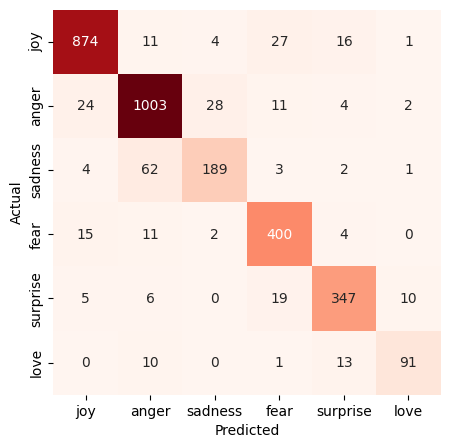

In [52]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, xticklabels=label2id.keys(), yticklabels=label2id.keys(), fmt='d', cbar=False, cmap='Reds')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## Build Prediction Function and Store Model

In [53]:
text = "I am super happy today. I got it done. Finally!!"

def get_prediction(text):
    input_encoded = tokenizer(text, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = model(**input_encoded)

    logits = outputs.logits

    pred = torch.argmax(logits, dim=1).item()
    return id2label[pred]

get_prediction(text)

'joy'

In [54]:
trainer.save_model("bert-base-uncased-sentiment-model")


In [55]:
# use pipeline for prediciton
from transformers import pipeline

classifier = pipeline('text-classification', model= 'bert-base-uncased-sentiment-model')

classifier([text, 'hello, how are you?', "love you", "i am feeling low"])

Device set to use cuda:0


[{'label': 'joy', 'score': 0.9464852809906006},
 {'label': 'joy', 'score': 0.7055653929710388},
 {'label': 'love', 'score': 0.6851125955581665},
 {'label': 'sadness', 'score': 0.9632183313369751}]